In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import scipy.optimize


1 - serie de taylor

Erro taylor1 - 36.36%
Erro taylor2 - 18.18%
Erro taylor3 - 0.00%


Text(0, 0.5, 'f(x)')

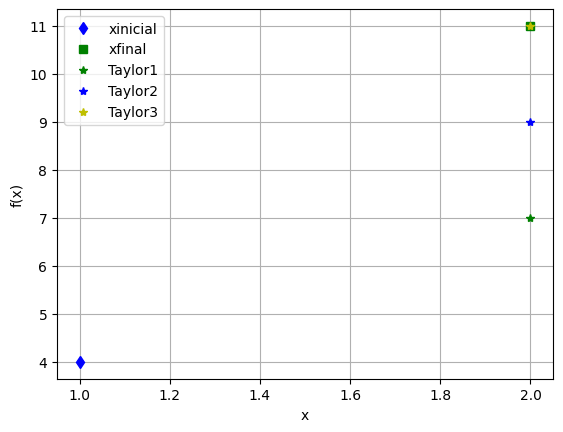

In [ ]:



xinicial = 1
xfinal= 2

h = 1

f= lambda x: 2*x**3 - 4*x**2 + 5*x + 1 
df = lambda x: 6*x**2 - 8*x + 5 
df2 = lambda x: 12*x - 8
df3 = lambda x: 12

xdiferenca = xfinal - xinicial

taylor1 = f(xinicial) + df(xinicial) * (xdiferenca)
taylor2 = taylor1 + (df2(xinicial) * (xdiferenca**2))/2
taylor3 = taylor2 + (df3(xinicial) * (xdiferenca**3))/6


erro1 = ((f(xfinal) - taylor1)/ f(xfinal)) * 100
erro2 = ((f(xfinal) - taylor2)/ f(xfinal)) * 100
erro3 = ((f(xfinal)- taylor3)/f(xfinal)) * 100

print(f"Erro taylor1 - {erro1:.2f}%")
print(f"Erro taylor2 - {erro2:.2f}%")
print(f"Erro taylor3 - {erro3:.2f}%")


plt.plot(xinicial, f(xinicial), 'bd', label = 'xinicial')
plt.plot(xfinal, f(xfinal), 'sg', label = 'xfinal')
plt.plot(xfinal, taylor1, '*g', label = 'Taylor1')
plt.plot(xfinal, taylor2, '*b', label = 'Taylor2')
plt.plot(xfinal, taylor3, '*y', label = 'Taylor3')



plt.grid()
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')

2 - derivacao numerica

[ 2.5   4.5   8.25 11.75 13.5 ]


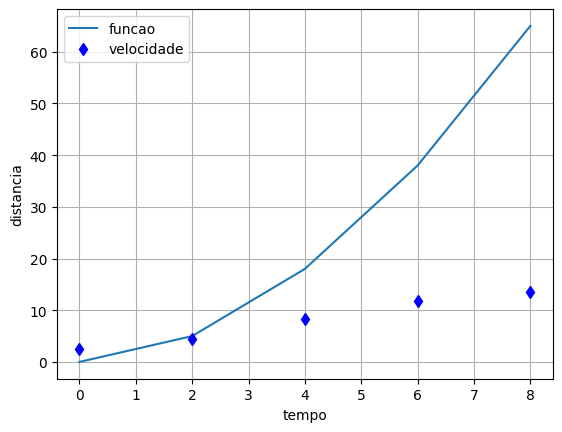

In [33]:
tempo = np.array([0, 2, 4, 6, 8])
distancia = np.array([0, 5, 18, 38, 65])

h = tempo[1] - tempo[0] ## nao precisa desse h, so se eu fosse fazer a mao
plt.plot(tempo, distancia, label = 'funcao')
velocidade = np.gradient(distancia, tempo)
plt.plot(tempo, velocidade, 'bd', label = 'velocidade')
print(velocidade)

plt.grid()
plt.legend()
plt.xlabel('tempo')
plt.ylabel('distancia')
plt.show()




3 -     derivacao numerica com funcao

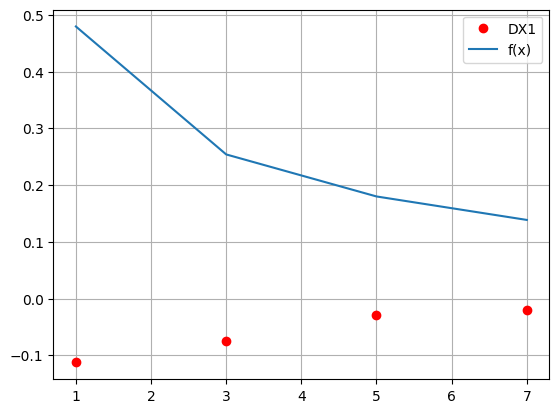

In [ ]:
fx = lambda x: np.sin(0.5*np.sqrt(x))/x

x1 = np.array([1,3,5,7])
x2 = np.array([1,2,3,4,5,6,7])
y1 = fx(x1)
y2 = fx(x2)
dy1 = np.gradient(y1, x1)
dy2 = np.gradient(y2,x2)
plt.plot(x1, dy1, "ro", label="DX1")
plt.plot(x1, y1, label="f(x)")
plt.plot(x2, dy2, '*y', label = 'DX2')

plt.grid()
plt.legend()
plt.show()

4- bisseccao

0.6823278038264107


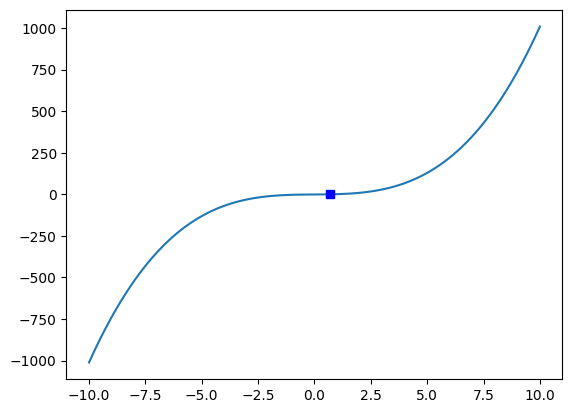

In [56]:
## encontrar a raiz


f = lambda x: x**3 + x - 1
xl = 0
xu = 1

raiz = scipy.optimize.bisect(f, xl, xu)
print(raiz)
linha = np.linspace(-10, 10, 100)
plt.plot(linha, f(linha), label = 'bisseccao')
plt.plot(raiz, 0, 'sb', label = 'raiz')
plt.show()


5 - newton e secante

Raiz encontrada por Newton-Raphson: 1.19413
Raiz encontrada por Secante: 1.19413


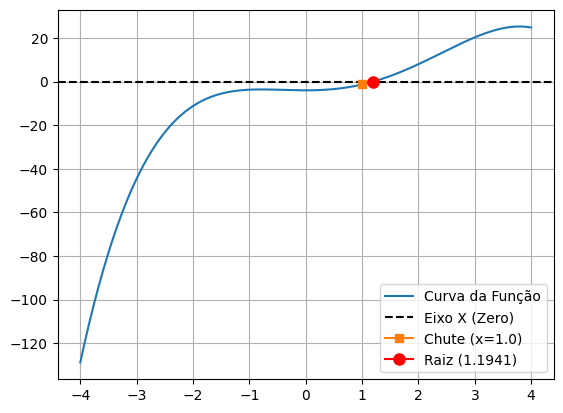

In [76]:
## objetivo eh achar a raiz tb

f = lambda x: -4 + 1.8*x**2 + 1.2*x**3 - 0.3*x**4
df = lambda x: 3.6*x + 3.6*x**2 - 1.2*x**3


chute_inicial = float(input("Digite o chute inicial: "))

raiz_newton = scipy.optimize.newton(f, chute_inicial, df)
print(f"Raiz encontrada por Newton-Raphson: {raiz_newton:.5f}")

raiz_secante = scipy.optimize.newton(f, chute_inicial)
print(f"Raiz encontrada por Secante: {raiz_secante:.5f}")

# 1. O linspace: Fixo entre -4 e 4 (com 200 pontos) para não espremer o gráfico
linha_x = np.linspace(-4, 4, 200)

# 2. Os plots: A curva, a linha do zero, o seu chute e o resultado
plt.plot(linha_x, f(linha_x), label='Curva da Função')
plt.axhline(0, color='black', linestyle='--', label='Eixo X (Zero)') 
plt.plot(chute_inicial, f(chute_inicial), marker='s', markersize=6, label=f'Chute (x={chute_inicial})')
plt.plot(raiz_newton, 0, marker='o', color='red', markersize=8, label=f'Raiz ({raiz_newton:.4f})')

plt.grid()
plt.legend()
plt.show()

6 - otimizacao

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -378.9454583951304
        x: [ 6.208e+00]
      nit: 5
      jac: [ 3.815e-06]
 hess_inv: [[ 2.248e-02]]
     nfev: 12
     njev: 6


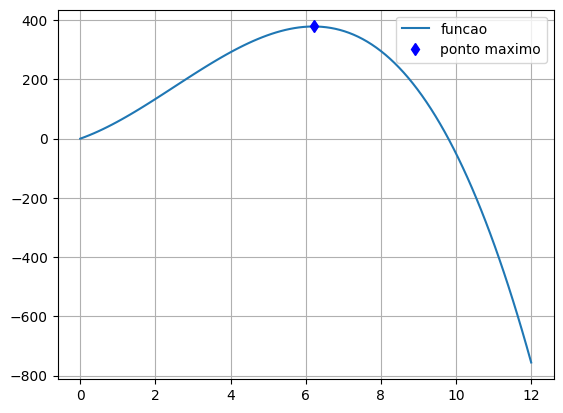

In [93]:
f = lambda x: (45*x + 15*x**2 - 2*x**3)
finv = lambda x: -1*(45*x + 15*x**2 - 2*x**3)

x = 5

resultado = scipy.optimize.minimize(finv, x)
maximo = resultado.x

linha = np.linspace(0,12,100)

plt.plot(linha, f(linha), label = 'funcao')
plt.plot(maximo, f(maximo), 'bd', label = 'ponto maximo')
print(resultado)

plt.grid()
plt.legend()


7 - REGULA FALSI (NA MAO PQ SO TEM NA MAO)

In [ ]:
def f(x):
    return np.sin(10x) + np.cos(3x)

xl = 4.5 
xu = 5.0 
erro = 0.000001

xr = (xu * f(xl) - xl * f(xu)) / (f(xl) - f(xu))

while abs(f(xr)) > erro:

    if (f(xl) * f(xr)) < 0:
        xu = xr
    else:
        xl = xr

    xr = (xu * f(xl) - xl * f(xu)) / (f(xl) - f(xu))

x = np.linspace(4.5, 5.0, 2000)

print(f"Raiz: {xr:.4f}")

plt.plot(x, f(x))
plt.plot(xr, 0, 'ro', label='raiz')
plt.legend()
plt.grid()
plt.show()

SyntaxError: invalid syntax (3932996669.py, line 6)